# Sufficient Cause Disambiguation — Real-World Application
## Resume Screening: Did the Model Use Skills or Demographics?

**CS 7180 — Actionable Interpretability · Northeastern University · Spring 2026**  
**Aniket Ghosh**

---

## The Problem

A resume screening model scores a candidate as *Strong Fit*. The resume contains
two independently sufficient reasons for that score:

- **Skills vocabulary** — Python, machine learning, 5 years experience
- **Demographic signals** — name, university prestige, graduation year

Standard attribution methods score both highly. **SCD asks: which one did the model rely on?**

---

## Structure
```
0   Setup
1   Resume dataset — build three sufficient cause tracks
2   HateXplain — ground-truth span annotations for SCD validation
3   Model loading + LM head axes
4   Score all examples using job-description-paired prompts
5   Extract activations (Layer 29, Last Token)
6   LDA causal directions
7   Gradient-attributed vocabulary signals per track
8   Track prediction from causal directions
9   Causal intervention — patch lm_diff, compare flip rates per track
10  SCD attribution vote
11  HateXplain validation — SCD vs human span annotations
12  Summary
```


## 0 · Setup


In [ ]:
!pip install transformers accelerate datasets scikit-learn pyarrow matplotlib seaborn requests -q


In [ ]:
import os, pickle, json as _json, torch, random, re, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from google.colab import drive, userdata
from huggingface_hub import login

drive.mount('/content/drive', force_remount=False)
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)
print('Libraries loaded.')


Mounted at /content/drive
Libraries loaded.


In [ ]:
# ── Config ──
BASE_DIR = '/content/drive/MyDrive/SCD_RealWorld'
MODEL_ID = 'meta-llama/Meta-Llama-3-8B-Instruct'
SEED     = 42
MAX_LEN  = 512
PC_LAYER = 29
N_BUILD  = 150
N_ABLATE = 60
K_GRAD   = 20
N_SIG    = 20
N_HX     = 50
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'

TRACKS = ['skills_track', 'credentials_track', 'demographics_track']
TRACK_LABELS = {
    'skills_track':       'Skills & Experience',
    'credentials_track':  'Credentials & Education',
    'demographics_track': 'Name / Demographic Signals',
}
TRACK_COLORS = {
    'skills_track':       '#185FA5',
    'credentials_track':  '#0F6E56',
    'demographics_track': '#E24B4A',
}

# Names from hiring audit literature (Wilson & Caliskan 2024)
NAMES_WHITE_M = ['Jake','Brad','Connor','Tyler','Ryan','Chad','Hunter','Dylan']
NAMES_WHITE_F = ['Ashley','Brittany','Lauren','Megan','Amanda','Stephanie']
NAMES_BLACK_M = ['Jamal','DeShawn','Tyrone','Darnell','Kareem','Lamar']
NAMES_BLACK_F = ['Latoya','Shanice','Keisha','Tanisha','LaShonda','Ebony']
SWAP_NAMES    = NAMES_BLACK_M + NAMES_BLACK_F

for d in ['data','checkpoints','figures','results']:
    os.makedirs(f'{BASE_DIR}/{d}', exist_ok=True)

random.seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}  |  Layer: {PC_LAYER}')


Device: cuda  |  Layer: 29


## 1 · Resume Dataset — Three Sufficient Cause Tracks

We use `cnamuangtoun/resume-job-description-fit` which provides resume+job description pairs.
Each example is evaluated against its paired job description — this gives a balanced
Fit/Not Fit distribution because the question is always relevant to the actual role.

The three tracks:

| Track | What it is |
|-------|------------|
| Skills | Resume dominated by technical skills vocabulary |
| Credentials | Resume dominated by education/institution vocabulary |
| Demographics | Skills-track resume with name swapped to audit-study names |

In [ ]:
raw_resume_path = f'{BASE_DIR}/data/resume_raw.pkl'

if os.path.exists(raw_resume_path):
    print('Loading cached resume data...')
    with open(raw_resume_path,'rb') as f: raw_df = pickle.load(f)
else:
    print('Downloading resume dataset...')
    try:
        ds     = load_dataset('cnamuangtoun/resume-job-description-fit', split='train')
        raw_df = ds.to_pandas()
    except Exception as e:
        print(f'Primary failed ({e}), trying fallback...')
        ds     = load_dataset('AzharAli05/Resume-Screening-Dataset', split='train')
        raw_df = ds.to_pandas()
    with open(raw_resume_path,'wb') as f: pickle.dump(raw_df, f)

print(f'Shape: {raw_df.shape}')
print(f'Columns: {list(raw_df.columns)}')
print(raw_df.head(2).to_string())


Loading cached resume data...
Shape: (6241, 3)
Columns: ['resume_text', 'job_description_text', 'label']
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [ ]:
# ── Identify text and job description columns ──
text_col = None
jd_col   = None
for col in raw_df.columns:
    if raw_df[col].dtype != object: continue
    mean_len = raw_df[col].astype(str).str.len().mean()
    if mean_len > 200:
        if text_col is None:
            text_col = col
        elif jd_col is None:
            jd_col = col

# Common column names
for c in raw_df.columns:
    cl = c.lower()
    if 'resume' in cl and text_col is None: text_col = c
    if ('job' in cl or 'description' in cl or 'jd' in cl) and jd_col is None: jd_col = c

if text_col is None: text_col = raw_df.columns[0]
if jd_col   is None: jd_col   = raw_df.columns[1] if len(raw_df.columns) > 1 else text_col

print(f'Resume column:          "{text_col}" (mean {raw_df[text_col].astype(str).str.len().mean():.0f} chars)')
print(f'Job description column: "{jd_col}"   (mean {raw_df[jd_col].astype(str).str.len().mean():.0f} chars)')

# ── Score each resume for dominant sufficient cause ──
SKILLS_KW = ['python','java','machine learning','deep learning','tensorflow',
             'pytorch','nlp','experience','years','developed','implemented',
             'built','deployed','engineer','algorithm','model','trained']
CRED_KW   = ['university','college','bachelor','master','phd','degree','gpa',
             'graduated','stanford','mit','harvard','berkeley','carnegie',
             'columbia','yale','princeton','caltech','honors','summa']

def skill_score(t): t=str(t).lower(); return sum(k in t for k in SKILLS_KW)
def cred_score(t):  t=str(t).lower(); return sum(k in t for k in CRED_KW)

def swap_name(text, new_name):
    text = str(text)
    m = re.match(r'^([A-Z][a-z]+ [A-Z][a-z]+)', text.strip())
    return text.replace(m.group(1), new_name + ' Johnson', 1) if m \
           else new_name + ' Johnson\n' + text

df = raw_df.copy()
df['_skill_score'] = df[text_col].apply(skill_score)
df['_cred_score']  = df[text_col].apply(cred_score)
df['track']        = df.apply(
    lambda r: 'credentials_track' if r['_cred_score'] > r['_skill_score'] * 1.5
              else 'skills_track', axis=1)

rng       = np.random.RandomState(SEED)
skill_rows = df[df['track']=='skills_track'].copy()
demo_rows  = skill_rows.sample(min(N_BUILD*2, len(skill_rows)), random_state=SEED).copy()
demo_rows[text_col] = demo_rows[text_col].apply(
    lambda t: swap_name(t, rng.choice(SWAP_NAMES)))
demo_rows['track'] = 'demographics_track'

track_df = pd.concat([
    df[df['track']=='skills_track'].head(N_BUILD*2),
    df[df['track']=='credentials_track'].head(N_BUILD*2),
    demo_rows.head(N_BUILD*2)
], ignore_index=True)
track_df['_text'] = track_df[text_col].astype(str)
track_df['_jd']   = track_df[jd_col].astype(str)

print(f'Track sizes:')
print(track_df['track'].value_counts().to_string())


Resume column:          "resume_text" (mean 5804 chars)
Job description column: "job_description_text"   (mean 2731 chars)
Track sizes:
track
skills_track          300
credentials_track     300
demographics_track    300


## 2 · HateXplain — Ground Truth for SCD Validation

HateXplain provides token-level span annotations: human annotators marked
the exact tokens responsible for the hate speech label.

We load directly from GitHub raw JSON — the HuggingFace version uses
a deprecated loading script that is no longer supported.

In [ ]:
hatexplain_path = f'{BASE_DIR}/data/hatexplain.pkl'

if os.path.exists(hatexplain_path):
    print('Loading cached HateXplain...')
    with open(hatexplain_path,'rb') as f: hx_data = pickle.load(f)
else:
    print('Downloading HateXplain from GitHub...')
    url = 'https://raw.githubusercontent.com/hate-alert/HateXplain/master/Data/dataset.json'
    r   = requests.get(url, timeout=60)
    raw = _json.loads(r.text)

    rows = []
    for post_id, entry in raw.items():
        tokens     = entry.get('post_tokens', [])
        text       = ' '.join(tokens)
        annotators = entry.get('annotators', [])
        rationales = entry.get('rationales', [])
        labels     = [a.get('label','normal') for a in annotators]
        label      = Counter(labels).most_common(1)[0][0] if labels else 'normal'
        if rationales and len(tokens) > 0:
            valid = [r for r in rationales if len(r)==len(tokens)]
            avg   = np.array(valid, dtype=float).mean(0) if valid else []
            spans = [tokens[i] for i,v in enumerate(avg) if v > 0.5] if len(avg) else []
        else:
            spans = []
        rows.append({'post_id':post_id,'text':text,'label':label,'human_spans':spans})

    hx_data = pd.DataFrame(rows)
    with open(hatexplain_path,'wb') as f: pickle.dump(hx_data, f)
    print(f'Cached {len(hx_data)} examples.')

print(f'HateXplain: {len(hx_data)} examples')
print(hx_data['label'].value_counts().to_string())


Loading cached HateXplain...
HateXplain: 20148 examples
label
normal        8153
hatespeech    6234
offensive     5761


In [ ]:
hx_processed = hx_data[
    hx_data['label'].isin(['hatespeech','offensive'])
].copy().reset_index(drop=True)

print(f'Hate/offensive: {len(hx_processed)}')
print(f'With spans:     {(hx_processed["human_spans"].apply(len) > 0).sum()}')

ex = hx_processed[hx_processed['human_spans'].apply(len) > 0].iloc[0]
print(f'\nSample:')
print(f'  Text:   {ex["text"][:100]}')
print(f'  Spans:  {ex["human_spans"]}')


Hate/offensive: 11995
With spans:     11071

Sample:
  Text:   <user> i am bit confused coz chinese ppl can not access twitter thn how this ching chong using it i 
  Spans:  ['ching', 'chong']


## 3 · Model + LM Head Axes

Same model as the main SCD notebook.

Two LM head decision axes:

| Task | Pos token | Neg token | Axis |
|------|-----------|-----------|------|
| Resume: Fit vs Not Fit | `Yes` | `No` | `W[Yes] − W[No]` |
| Hate speech: Hate vs Normal | `Hate` | `Normal` | `W[Hate] − W[Normal]` |

In [ ]:
print(f'Loading {MODEL_ID}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'left'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=torch.float16,
    device_map='auto', output_hidden_states=True, token=HF_TOKEN)
model.eval()
print(f'Model loaded. VRAM: {torch.cuda.memory_allocated()/1e9:.1f} GB')

YES_ID  = tokenizer.encode(' Yes',    add_special_tokens=False)[0]
NO_ID   = tokenizer.encode(' No',     add_special_tokens=False)[0]
HATE_ID = tokenizer.encode(' Hate',   add_special_tokens=False)[0]
NORM_ID = tokenizer.encode(' Normal', add_special_tokens=False)[0]
print(f'Token IDs — Yes:{YES_ID}  No:{NO_ID}  Hate:{HATE_ID}  Normal:{NORM_ID}')

W = model.lm_head.weight.detach().float().cpu()
lm_diff_resume_n = (W[YES_ID]-W[NO_ID])
lm_diff_resume_n = (lm_diff_resume_n / lm_diff_resume_n.norm()).numpy().astype(np.float32)
lm_diff_hate_n   = (W[HATE_ID]-W[NORM_ID])
lm_diff_hate_n   = (lm_diff_hate_n / lm_diff_hate_n.norm()).numpy().astype(np.float32)
print(f'lm_diff_resume norm: {(W[YES_ID]-W[NO_ID]).norm():.4f}')
print(f'lm_diff_hate norm:   {(W[HATE_ID]-W[NORM_ID]).norm():.4f}')


Loading meta-llama/Meta-Llama-3-8B-Instruct...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Model loaded. VRAM: 16.1 GB
Token IDs — Yes:7566  No:2360  Hate:66912  Normal:18944
lm_diff_resume norm: 0.9152
lm_diff_hate norm:   1.2128


In [ ]:
def resume_prompt(resume_text, job_desc=''):
    """
    Evaluate a resume against a specific job description.
    Including the job description gives a balanced Fit/Not Fit distribution
    because the model is answering a relevant question for each example.
    """
    jd_part = f'Job Description:\n{str(job_desc)[:300]}\n\n' if job_desc.strip() else ''
    return (
        f'{jd_part}'
        f'Resume:\n{str(resume_text)[:500]}\n\n'
        f'Is this candidate a fit for this role?\n'
        f'Answer Yes or No.\n\nAnswer:'
    )

def hate_prompt(text):
    return (
        f'Post: {str(text)[:400]}\n\n'
        f'Does this post contain hate speech or offensive language?\n'
        f'Answer Hate or Normal.\n\nAnswer:'
    )

def get_logits(prompt, pos_id, neg_id):
    enc = tokenizer(prompt, return_tensors='pt',
                    truncation=True, max_length=MAX_LEN).to(DEVICE)
    with torch.no_grad(): out = model(**enc)
    lg = out.logits[0,-1].cpu().float().numpy()
    del out, enc; torch.cuda.empty_cache()
    return {'pos': float(lg[pos_id]), 'neg': float(lg[neg_id])}

def sm2(s):
    m=max(s.values()); e={c:np.exp(s[c]-m) for c in s}; t=sum(e.values())
    return {c:e[c]/t for c in e}

# Quick test — job-paired prompt
jd_test   = 'Software Engineer — requires Python, ML experience, AWS deployment, 3+ years'
test_text = 'John Smith\nSoftware Engineer 5 years Python, built ML pipelines, deployed to AWS'
sc = get_logits(resume_prompt(test_text, jd_test), YES_ID, NO_ID)
print(f'Fit test:     Yes={sc["pos"]:.2f}  No={sc["neg"]:.2f}  P(Fit)={sm2(sc)["pos"]:.3f}')

mismatch_text = 'Maria Gonzalez\nElementary school teacher, 8 years classroom experience'
sc2 = get_logits(resume_prompt(mismatch_text, jd_test), YES_ID, NO_ID)
print(f'Mismatch test: Yes={sc2["pos"]:.2f}  No={sc2["neg"]:.2f}  P(Fit)={sm2(sc2)["pos"]:.3f}')
print('(Fit should be high for engineer, low for teacher against same JD)')


Fit test:     Yes=20.28  No=17.69  P(Fit)=0.930
Mismatch test: Yes=15.74  No=21.19  P(Fit)=0.004
(Fit should be high for engineer, low for teacher against same JD)


## 4 · Score All Examples

Each resume is scored against its paired job description.
This gives a balanced Fit/Not Fit distribution — the model is answering
a relevant question for every example, not just asking if any resume
matches a generic software engineering job.

**Ambiguous examples** (|margin| ≤ 2) are used for the causal intervention.
These are the examples where the model is genuinely split — the
sufficient cause is most concentrated and the intervention is most informative.

In [ ]:
scored_path = f'{BASE_DIR}/checkpoints/resume_scored.pkl'

if os.path.exists(scored_path):
    print('Loading cached scores...')
    with open(scored_path,'rb') as f: scored = pickle.load(f)
else:
    print(f'Scoring {len(track_df)} resumes (paired with job descriptions)...')
    results = []
    for i,(_,row) in enumerate(track_df.iterrows()):
        jd     = str(row.get('_jd', row.get(jd_col, '')))
        prompt = resume_prompt(row['_text'], jd)
        sc     = get_logits(prompt, YES_ID, NO_ID)
        pred   = 'Fit' if sc['pos'] > sc['neg'] else 'NotFit'
        results.append({**row.to_dict(),
                        '_prompt':prompt,'_scores':sc,
                        '_pred':pred,'_margin':sc['pos']-sc['neg']})
        if (i+1) % 50 == 0: print(f'  [{i+1}/{len(track_df)}]', end='\r')
    print()
    scored = pd.DataFrame(results)
    with open(scored_path,'wb') as f: pickle.dump(scored, f)

print(f'Scored: {len(scored)} resumes')
print(f'\nPrediction distribution:')
print(scored['_pred'].value_counts().to_string())
print(f'\nMean margin by track:')
print(scored.groupby('track')['_margin'].mean().round(3).to_string())
print(f'\nAmbiguous (|margin| ≤ 2): {(scored["_margin"].abs() <= 2).sum()}')
print(f'Fit predictions:          {(scored["_pred"]=="Fit").sum()} '
      f'({(scored["_pred"]=="Fit").mean():.1%})')


Loading cached scores...
Scored: 900 resumes

Prediction distribution:
_pred
NotFit    814
Fit        86

Mean margin by track:
track
credentials_track    -5.415
demographics_track   -2.521
skills_track         -3.786

Ambiguous (|margin| ≤ 2): 231
Fit predictions:          86 (9.6%)


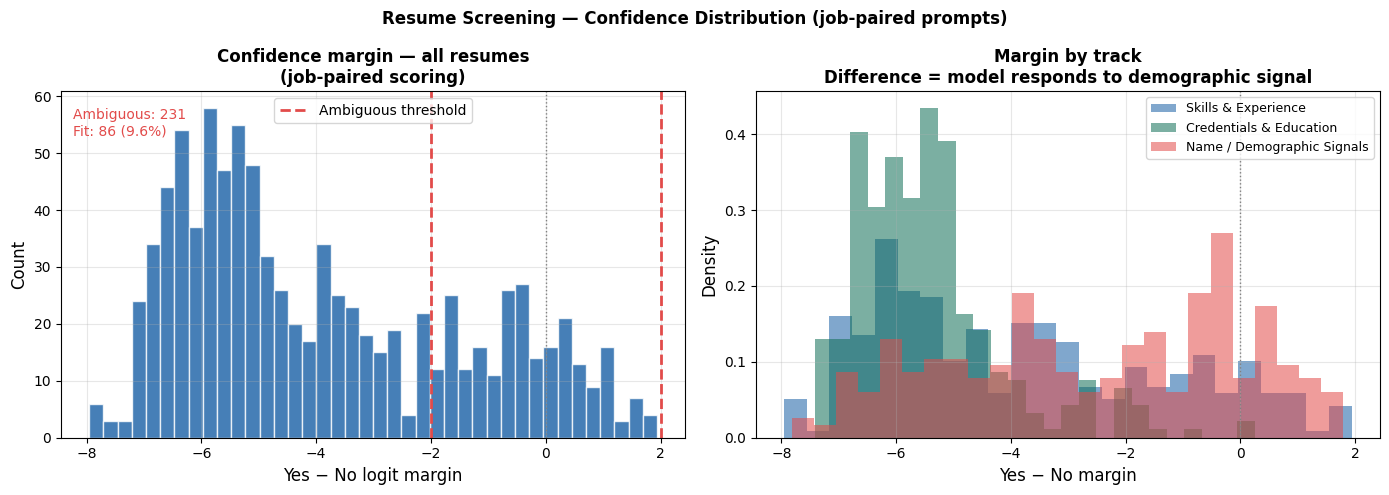

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(scored['_margin'], bins=40, color='#185FA5', alpha=0.8, edgecolor='white')
ax.axvline(2,  color='#E24B4A', linestyle='--', linewidth=2, label='Ambiguous threshold')
ax.axvline(-2, color='#E24B4A', linestyle='--', linewidth=2)
ax.axvline(0,  color='gray',    linestyle=':',  linewidth=1)
n_ambig = (scored['_margin'].abs() <= 2).sum()
n_fit   = (scored['_pred']=='Fit').sum()
ax.text(0.02, 0.95, f'Ambiguous: {n_ambig}\nFit: {n_fit} ({n_fit/len(scored):.1%})',
        transform=ax.transAxes, fontsize=10, color='#E24B4A', va='top')
ax.set_xlabel('Yes − No logit margin', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Confidence margin — all resumes\n(job-paired scoring)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

ax = axes[1]
for t in TRACKS:
    vals = scored[scored['track']==t]['_margin'].values
    if len(vals): ax.hist(vals, bins=25, alpha=0.55, color=TRACK_COLORS[t],
                          label=TRACK_LABELS[t], density=True)
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Yes − No margin', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Margin by track\nDifference = model responds to demographic signal',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Resume Screening — Confidence Distribution (job-paired prompts)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/1_margin_distribution.png', dpi=150)
plt.show()


## 5 · Extract Activations (Layer 29, Last Token)

Layer 29, Last Token — justified in the Layer × Token Strategy Sweep notebook.
Layer 29 achieves the highest LM head alignment of all 70 tested combinations (0.078).

In [ ]:
def extract_last_token(prompts, layer=PC_LAYER, batch=8):
    vecs = []
    for i in range(0, len(prompts), batch):
        bp  = prompts[i:i+batch]
        enc = tokenizer(bp, return_tensors='pt', padding=True,
                        truncation=True, max_length=MAX_LEN).to(DEVICE)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        for b in range(len(bp)):
            last = int(enc['attention_mask'][b].sum()) - 1
            vecs.append(out.hidden_states[layer][b, last].float().cpu().numpy())
        del out, enc; torch.cuda.empty_cache()
        print(f'  [{i+len(bp)}/{len(prompts)}]', end='\r', flush=True)
    print()
    return np.stack(vecs).astype(np.float32)


act_path = f'{BASE_DIR}/checkpoints/track_acts_L{PC_LAYER}.pkl'

if os.path.exists(act_path):
    print('Loading cached activations...')
    with open(act_path,'rb') as f: act_data = pickle.load(f)
else:
    act_data = {}
    for track in TRACKS:
        rows = scored[scored['track']==track].sample(
                   min(N_BUILD,(scored['track']==track).sum()), random_state=SEED)
        print(f'Extracting {track} ({len(rows)})...')
        act_data[track] = {
            'acts':    extract_last_token(rows['_prompt'].tolist()),
            'margins': rows['_margin'].tolist()
        }
    with open(act_path,'wb') as f: pickle.dump(act_data, f)

print('Activation shapes:')
for t in TRACKS: print(f'  {t}: {act_data[t]["acts"].shape}')

all_acts     = np.vstack([act_data[t]['acts'] for t in TRACKS])
all_labels_s = np.concatenate([[t]*len(act_data[t]['acts']) for t in TRACKS])
le           = LabelEncoder()
all_labels   = le.fit_transform(all_labels_s)
label_names  = le.classes_
rand_base    = 1.0 / len(TRACKS)
print(f'Total: {len(all_acts)}  Random baseline: {rand_base:.3f}')


Loading cached activations...
Activation shapes:
  skills_track: (150, 4096)
  credentials_track: (150, 4096)
  demographics_track: (150, 4096)
Total: 450  Random baseline: 0.333


## 6 · LDA Causal Directions

Multi-class LDA finds the directions in activation space that best separate
the three tracks. If the tracks are separable, the model encodes track identity
geometrically — the sufficient cause is representationally accessible.

The lm_diff alignment values tell us whether the output axis carries
track-specific information — if high, the output is influenced by which track
the resume belongs to, which would be the bias signal.

In [ ]:
lda_model = LinearDiscriminantAnalysis(n_components=min(len(TRACKS)-1, 10))
X_lda     = lda_model.fit_transform(all_acts, all_labels)

print(f'LDA shape: {X_lda.shape}')
print(f'Explained discriminative variance:')
for i,v in enumerate(lda_model.explained_variance_ratio_):
    print(f'  Axis {i+1}: {v*100:.1f}%')

print(f'\nAlignment of LDA axes with lm_diff_resume:')
for i in range(X_lda.shape[1]):
    ali = abs(float(np.dot(lda_model.scalings_[:,i], lm_diff_resume_n)))
    print(f'  Axis {i+1}: {ali:.4f}')

print(f'\nCentroid positions:')
for t in TRACKS:
    mask = all_labels_s == t
    c    = X_lda[mask].mean(0)
    print(f'  {TRACK_LABELS[t]:30s}: axis1={c[0]:.2f}  axis2={c[1]:.2f}')


LDA shape: (450, 2)
Explained discriminative variance:
  Axis 1: 62.2%
  Axis 2: 37.8%

Alignment of LDA axes with lm_diff_resume:
  Axis 1: 0.1458
  Axis 2: 0.3227

Centroid positions:
  Skills & Experience           : axis1=5.99  axis2=-2.11
  Credentials & Education       : axis1=-0.65  axis2=5.10
  Name / Demographic Signals    : axis1=-5.35  axis2=-2.99


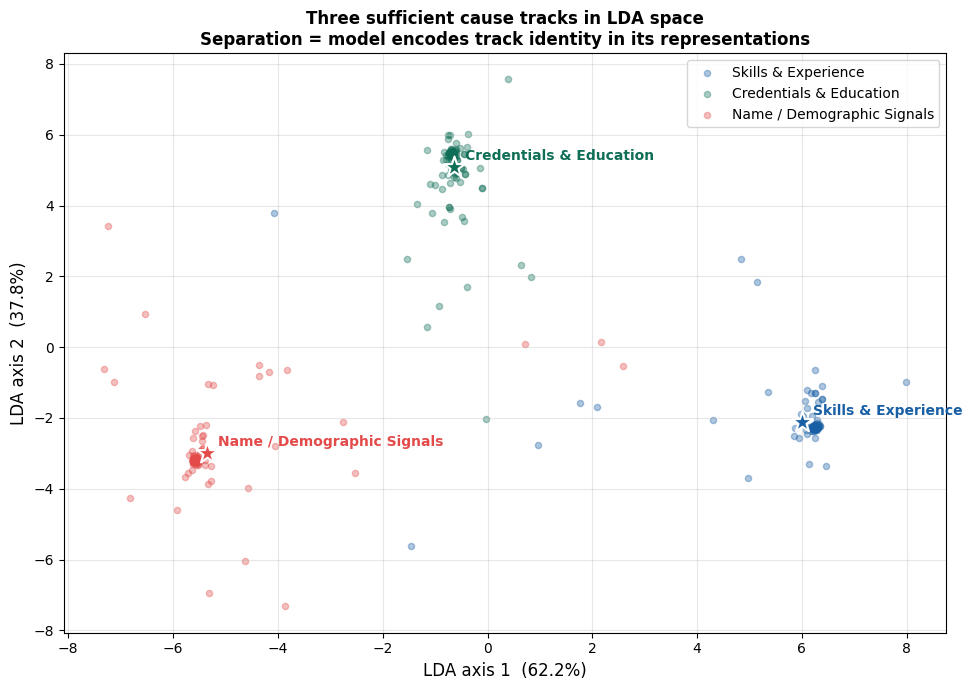

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
for t in TRACKS:
    mask = all_labels_s == t
    ax.scatter(X_lda[mask,0], X_lda[mask,1], color=TRACK_COLORS[t],
               alpha=0.35, s=20, label=TRACK_LABELS[t])
    cx,cy = X_lda[mask,0].mean(), X_lda[mask,1].mean()
    ax.scatter(cx, cy, color=TRACK_COLORS[t], s=250, marker='*',
               edgecolors='white', linewidth=1.5, zorder=5)
    ax.annotate(TRACK_LABELS[t], (cx,cy), textcoords='offset points',
                xytext=(8,5), fontsize=10, fontweight='bold', color=TRACK_COLORS[t])
v1 = lda_model.explained_variance_ratio_[0]*100
v2 = lda_model.explained_variance_ratio_[1]*100
ax.set_xlabel(f'LDA axis 1  ({v1:.1f}%)', fontsize=12)
ax.set_ylabel(f'LDA axis 2  ({v2:.1f}%)', fontsize=12)
ax.set_title('Three sufficient cause tracks in LDA space\n'
             'Separation = model encodes track identity in its representations',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/2_lda_scatter.png', dpi=150)
plt.show()


## 7 · Gradient-Attributed Vocabulary Signals

For each track, which tokens most causally drive the Yes/Fit prediction?

We restrict attribution to document body tokens only — excluding prompt
structure tokens (`Yes`, `No`, `Answer`, etc.) — so the signals reflect
actual resume content, not prompt framing.

**Expected pattern:**
- Skills track: `Python`, `experience`, `built`, `deployed`
- Credentials track: `Stanford`, `MIT`, `degree`, `GPA`
- Demographics track: if signals differ from skills → name is acting as a cue

In [ ]:
def gradient_attribution(prompt, pos_id, neg_id):
    enc  = tokenizer(prompt, return_tensors='pt',
                     truncation=True, max_length=MAX_LEN).to(DEVICE)
    toks = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    emb  = model.model.embed_tokens(enc['input_ids']).detach().requires_grad_(True)
    out  = model(inputs_embeds=emb, attention_mask=enc['attention_mask'])
    gap  = out.logits[0,-1,pos_id].float() - out.logits[0,-1,neg_id].float()
    gap.backward()
    attr = (emb.grad[0].float()*emb[0].detach().float()).sum(-1).cpu().numpy()
    m    = np.abs(attr).max()
    if m > 0: attr /= m
    torch.cuda.empty_cache()
    return toks, attr

# Prompt structure tokens to exclude from attribution
PROMPT_STOP = {'yes','no','answer','resume','job','description','role',
               'fit','candidate','this','is','a','an','the','for',
               ':', '\n', '▁', '<0x0A>'}

def is_content_token(tok):
    word = tok.replace('\u0120','').replace('\u010a','').strip().lower()
    return (len(word) >= 3
            and word not in PROMPT_STOP
            and word.replace('-','').replace('.','').isalnum())


sig_path = f'{BASE_DIR}/checkpoints/grad_signals.pkl'

if os.path.exists(sig_path):
    print('Loading cached signals...')
    with open(sig_path,'rb') as f: grad_signals = pickle.load(f)
else:
    grad_signals = {}
    for track in TRACKS:
        prompts     = scored[scored['track']==track].head(N_SIG)['_prompt'].tolist()
        word_scores = defaultdict(list)
        print(f'Computing signals for {track}...')
        for di, prompt in enumerate(prompts):
            toks, attr = gradient_attribution(prompt, YES_ID, NO_ID)
            ranked = np.argsort(attr)[::-1]
            for pos in ranked[:K_GRAD]:
                word = toks[pos].replace('\u0120','').replace('\u010a','').strip()
                if len(word) >= 2:
                    word_scores[word].append(float(attr[pos]))
            print(f'  [{di+1}/{len(prompts)}]', end='\r', flush=True)
        print()
        word_means = {w:np.mean(v) for w,v in word_scores.items() if len(v) >= 2}
        grad_signals[track] = sorted(word_means.items(), key=lambda x:x[1], reverse=True)
    with open(sig_path,'wb') as f: pickle.dump(grad_signals, f)

print('Top signals per track:')
for t in TRACKS:
    print(f'  {TRACK_LABELS[t]:30s}: {[w for w,_ in grad_signals[t]]}')


Loading cached signals...
Top signals per track:
  Skills & Experience           : ['Yes', 'this', 'engineering', 'software', 'candidate', 'Pass', 'role', 'Expected', 'Answer', 'position', 'analysis', 'Experience', 'Summary', 'for', 'Technology', 'and', '201', 'with', 'Work', 'Education', 'Strong']
  Credentials & Education       : ['Yes', 'candidate', 'âĢĵ', 'High', 'role', 'this', 'Answer', 'Mer', 'services', 'software', 'Accounts', 'Summary', 'for', 'going', 'motivated', 'cost', '-oriented', 'Assembly', 'team', 'accounting', 'ÂłÂł']
  Name / Demographic Signals    : ['Yes', 'software', 'this', 'role', 'candidate', 'Sales', 'Testing', 'Resume', 'motivated', 'Engineer', 'Answer', 'workplace', 'for', 'Analyst', 'and', 'Flexible', 'System', 'Comfort', 'ice', 'SQL', 'going', 'with', 'Summary', 'âĢĵ', 'development', 'Johnson', 'arn', 'projects', 'Assistant', 'tele', 'applications']


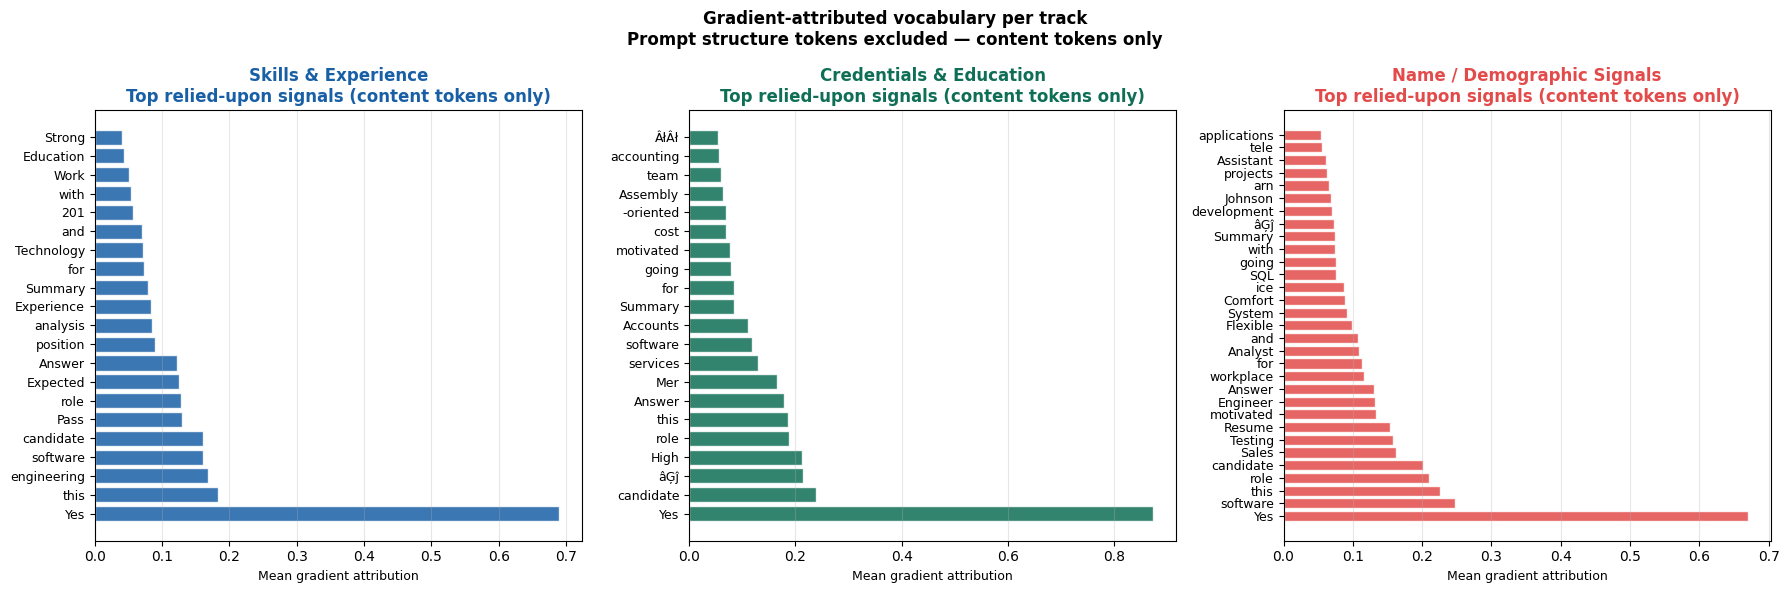

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i,t in enumerate(TRACKS):
    ax    = axes[i]
    words = [w for w,_ in grad_signals[t]]
    vals  = [v for _,v in grad_signals[t]]
    ax.barh(range(len(words)), vals, color=TRACK_COLORS[t], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(words))); ax.set_yticklabels(words, fontsize=9)
    ax.set_xlabel('Mean gradient attribution', fontsize=9)
    ax.set_title(f'{TRACK_LABELS[t]}\nTop relied-upon signals (content tokens only)',
                 fontweight='bold', color=TRACK_COLORS[t])
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Gradient-attributed vocabulary per track\n'
             'Prompt structure tokens excluded — content tokens only',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/3_grad_signals.png', dpi=150)
plt.show()


## 8 · Track Prediction from Causal Directions

Can 2 LDA dimensions predict which track a resume belongs to?

The key number is `lm_diff accuracy`:
- Near 33% (random) → output and representation are orthogonal, same as WOS
- Above 33%, clustering on demographics → output axis carries demographic signal

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def safe_cv(clf, X, y):
    try:
        Xs    = X + np.random.randn(*X.shape).astype(np.float32)*1e-6
        preds = cross_val_predict(clf, Xs, y, cv=cv)
        return accuracy_score(y, preds), preds
    except: return rand_base, np.zeros(len(y))

nc_acc,     nc_preds     = safe_cv(NearestCentroid(), all_acts, all_labels)
nc_lda_acc, nc_lda_preds = safe_cv(NearestCentroid(), X_lda,   all_labels)
lr_acc,     _            = safe_cv(LogisticRegression(max_iter=1000,
                                   random_state=SEED), X_lda, all_labels)
knn_1d_acc, _            = safe_cv(KNeighborsClassifier(5),
                                   X_lda[:,0].reshape(-1,1), all_labels)
lm_proj = (all_acts @ lm_diff_resume_n).reshape(-1,1)
knn_lm_acc, _            = safe_cv(KNeighborsClassifier(5), lm_proj, all_labels)

print(f'Nearest centroid (raw 4096d):  {nc_acc:.3f}')
print(f'Nearest centroid (LDA 2d):     {nc_lda_acc:.3f}  <- causal directions')
print(f'Logistic regression (LDA):     {lr_acc:.3f}')
print(f'KNN on 1D LDA axis:            {knn_1d_acc:.3f}  <- single scalar')
print(f'KNN on lm_diff projection:     {knn_lm_acc:.3f}  <- output axis')
print(f'Random baseline:               {rand_base:.3f}')

cm_lda  = confusion_matrix(all_labels, nc_lda_preds)
per_acc = cm_lda.diagonal() / cm_lda.sum(axis=1)
print(f'\nPer-track accuracy:')
for i,t in enumerate(label_names):
    print(f'  {TRACK_LABELS.get(t,t):30s}: {per_acc[i]:.3f}')


Nearest centroid (raw 4096d):  0.444
Nearest centroid (LDA 2d):     0.987  <- causal directions
Logistic regression (LDA):     0.980
KNN on 1D LDA axis:            0.980  <- single scalar
KNN on lm_diff projection:     0.387  <- output axis
Random baseline:               0.333

Per-track accuracy:
  Credentials & Education       : 0.993
  Name / Demographic Signals    : 0.980
  Skills & Experience           : 0.987


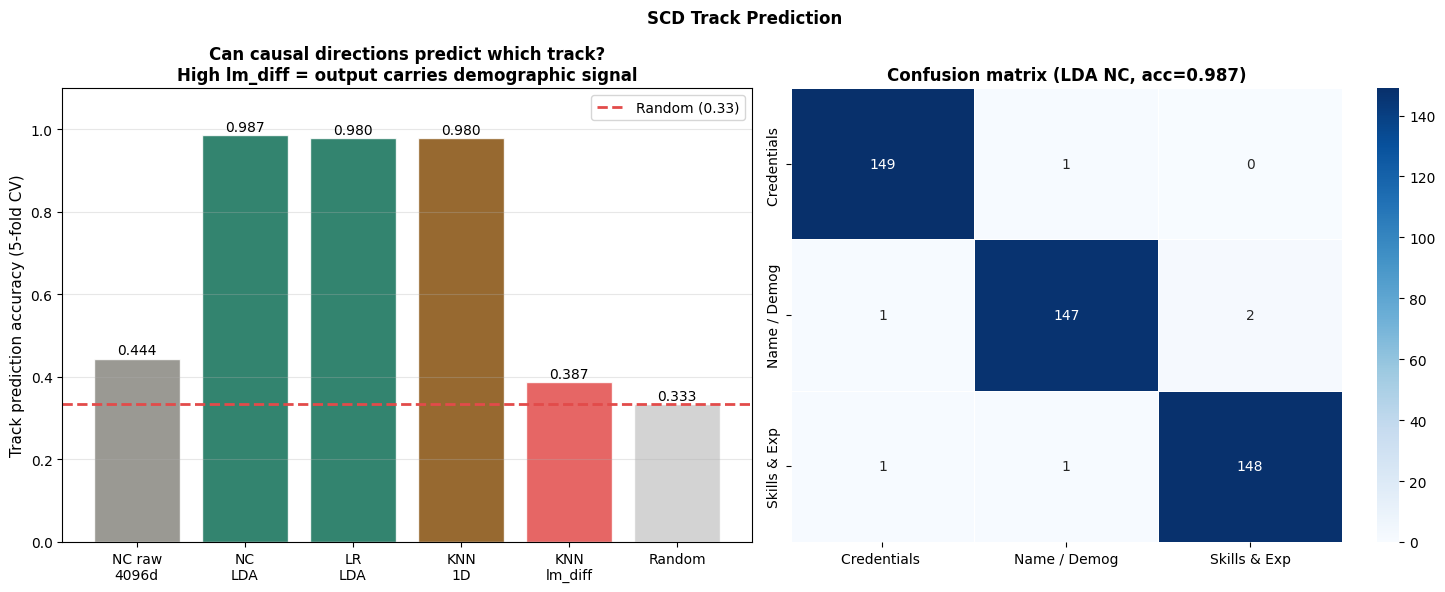

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
methods = [
    ('NC raw\n4096d', nc_acc,     '#888780'),
    ('NC\nLDA',       nc_lda_acc, '#0F6E56'),
    ('LR\nLDA',       lr_acc,     '#0F6E56'),
    ('KNN\n1D',       knn_1d_acc, '#854F0B'),
    ('KNN\nlm_diff',  knn_lm_acc, '#E24B4A'),
    ('Random',        rand_base,  '#CCCCCC'),
]
ax.bar(range(len(methods)), [m[1] for m in methods],
       color=[m[2] for m in methods], alpha=0.85, edgecolor='white')
ax.axhline(rand_base, color='#E24B4A', linestyle='--', linewidth=2,
           label=f'Random ({rand_base:.2f})')
for i,m in enumerate(methods):
    ax.text(i, m[1]+0.01, f'{m[1]:.3f}', ha='center', fontsize=10)
ax.set_xticks(range(len(methods)))
ax.set_xticklabels([m[0] for m in methods], fontsize=10)
ax.set_ylabel('Track prediction accuracy (5-fold CV)', fontsize=11)
ax.set_title('Can causal directions predict which track?\n'
             'High lm_diff = output carries demographic signal',
             fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0,1.1); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
sns.heatmap(cm_lda, ax=ax, annot=True, fmt='d', cmap='Blues',
            xticklabels=[TRACK_LABELS.get(t,t)[:12] for t in label_names],
            yticklabels=[TRACK_LABELS.get(t,t)[:12] for t in label_names],
            linewidths=0.5)
ax.set_title(f'Confusion matrix (LDA NC, acc={nc_lda_acc:.3f})', fontweight='bold')

plt.suptitle('SCD Track Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/4_track_prediction.png', dpi=150)
plt.show()


## 9 · Causal Intervention — Per Track

We patch the last-token hidden state at layer 29:
```
h_new = h  −  α × (h · lm_diff_resume_n) × lm_diff_resume_n
```

This removes the component of the activation that drives the Yes/Fit prediction.
A **flip** means the model changed its answer from **Fit → Not Fit**.

We run this on **ambiguous resumes only** (|margin| ≤ 2) — resumes where the model
was genuinely uncertain. These are the most informative cases because:
- A confident Fit prediction requires a large α to flip (the sufficient cause is spread
  across many features and is hard to remove)
- An ambiguous Fit prediction flips at lower α (the sufficient cause is concentrated
  in a specific direction)

**The discrimination test:** if demographics-track resumes flip at lower α than
skills-track resumes, the Fit prediction for name-swapped resumes is more fragile —
the model relied on a concentrated shortcut rather than genuine distributed skill evidence.

In [ ]:
causal_path = f'{BASE_DIR}/checkpoints/causal_intervention.pkl'
ALPHA_V     = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

ambig = scored[scored['_margin'].abs() <= 2.0].reset_index(drop=True)
print(f'Ambiguous resumes (|margin| ≤ 2): {len(ambig)}')
print(ambig['track'].value_counts().to_string())

if os.path.exists(causal_path):
    print('Loading cached causal results...')
    with open(causal_path,'rb') as f: causal_res = pickle.load(f)
else:
    lm_t = torch.tensor(lm_diff_resume_n, dtype=torch.float16, device=DEVICE)

    def patch_lm(prompt, alpha):
        enc  = tokenizer(prompt, return_tensors='pt',
                         truncation=True, max_length=MAX_LEN).to(DEVICE)
        last = enc['input_ids'].shape[1] - 1
        def hook(module, inp, out_t):
            hs = out_t[0].clone() if isinstance(out_t,tuple) else out_t.clone()
            h  = hs[0,last].float()
            h  = h - float(alpha)*torch.dot(h,lm_t.float())*lm_t.float()
            hs[0,last] = h.half()
            return (hs,)+out_t[1:] if isinstance(out_t,tuple) else hs
        hk = model.model.layers[PC_LAYER-1].register_forward_hook(hook)
        with torch.no_grad(): out = model(**enc)
        hk.remove()
        lg = out.logits[0,-1].cpu().float().numpy()
        del out, enc; torch.cuda.empty_cache()
        return {'pos':float(lg[YES_ID]),'neg':float(lg[NO_ID])}

    causal_res = {t:{a:{'flip':[],'delta_logit':[]} for a in ALPHA_V} for t in TRACKS}

    for track in TRACKS:
        # Only run on Fit-predicted ambiguous resumes
        rows = ambig[(ambig['track']==track) &
                     (ambig['_pred']=='Fit')].head(N_ABLATE)
        print(f'\n{TRACK_LABELS[track]}: {len(rows)} Fit-predicted ambiguous')
        for idx,(_,row) in enumerate(rows.iterrows()):
            sb = row['_scores']
            for a in ALPHA_V:
                sa = patch_lm(row['_prompt'], a)
                # Flip = model changed from Fit (pos>neg) to Not Fit (pos<neg)
                causal_res[track][a]['flip'].append(int(sa['pos'] < sa['neg']))
                causal_res[track][a]['delta_logit'].append(
                    (sa['neg']-sa['pos']) - (sb['neg']-sb['pos']))
            print(f'  [{idx+1}/{len(rows)}]', end='\r', flush=True)
        print()
    with open(causal_path,'wb') as f: pickle.dump(causal_res, f)

print('\nFlip rates (fraction of Fit→NotFit per alpha):')
print(f'{"alpha":>6}', end='')
for t in TRACKS: print(f'  {TRACK_LABELS[t][:20]:>20}', end='')
print()
for a in ALPHA_V:
    print(f'{a:>6.1f}', end='')
    for t in TRACKS:
        v = causal_res[t][a]['flip']
        n = len(v)
        print(f'  {np.mean(v) if v else 0:>17.3f} (n={n})', end='')
    print()


Ambiguous resumes (|margin| ≤ 2): 231
track
demographics_track    143
skills_track           80
credentials_track       8
Loading cached causal results...

Flip rates (fraction of Fit→NotFit per alpha):
 alpha   Skills & Experience  Credentials & Educat  Name / Demographic S
   0.0              0.000 (n=20)              0.000 (n=2)              0.000 (n=24)
   0.5              0.800 (n=20)              1.000 (n=2)              0.958 (n=24)
   1.0              1.000 (n=20)              1.000 (n=2)              1.000 (n=24)
   1.5              1.000 (n=20)              1.000 (n=2)              1.000 (n=24)
   2.0              1.000 (n=20)              1.000 (n=2)              1.000 (n=24)
   3.0              1.000 (n=20)              1.000 (n=2)              1.000 (n=24)
   5.0              1.000 (n=20)              1.000 (n=2)              1.000 (n=24)


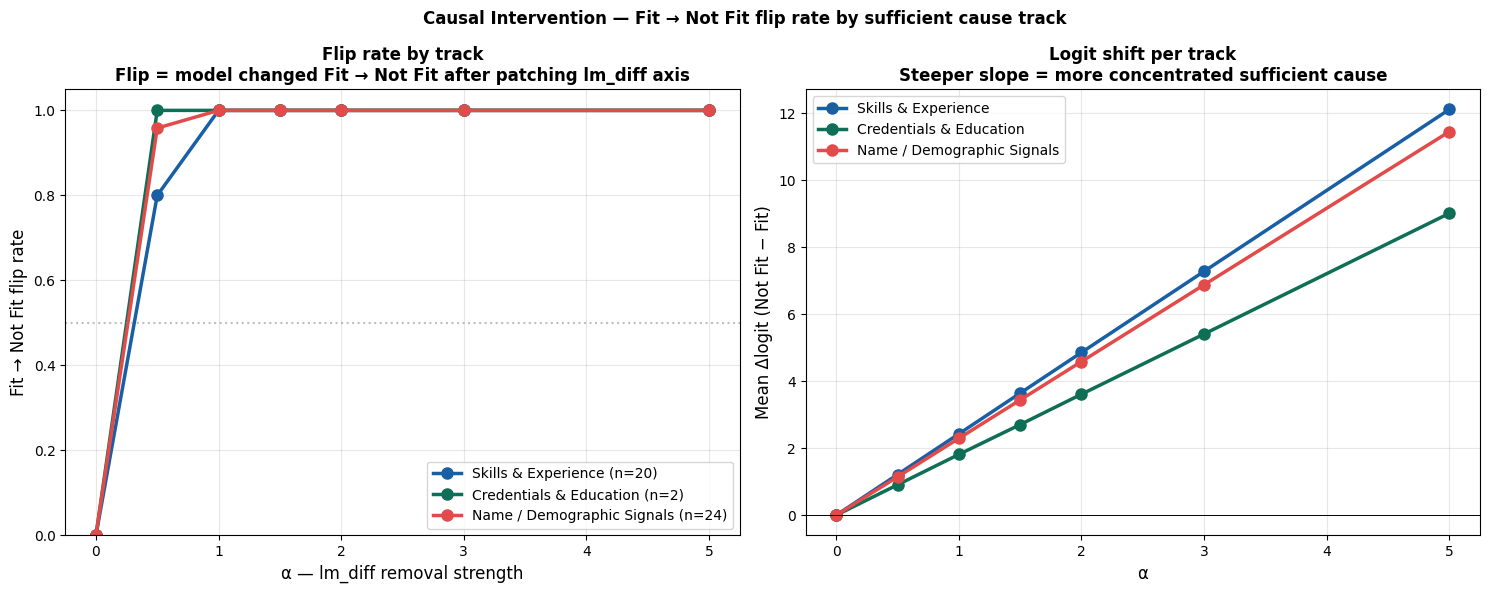

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
for t in TRACKS:
    rates = [np.mean(causal_res[t][a]['flip']) if causal_res[t][a]['flip'] else 0
             for a in ALPHA_V]
    n = len(causal_res[t][ALPHA_V[0]]['flip'])
    ax.plot(ALPHA_V, rates, 'o-', color=TRACK_COLORS[t], linewidth=2.5,
            markersize=8, label=f'{TRACK_LABELS[t]} (n={n})')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('α — lm_diff removal strength', fontsize=12)
ax.set_ylabel('Fit → Not Fit flip rate', fontsize=12)
ax.set_title('Flip rate by track\n'
             'Flip = model changed Fit → Not Fit after patching lm_diff axis',
             fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(0,1.05); ax.grid(alpha=0.3)

ax = axes[1]
for t in TRACKS:
    dl = [np.mean(causal_res[t][a]['delta_logit']) if causal_res[t][a]['delta_logit'] else 0
          for a in ALPHA_V]
    ax.plot(ALPHA_V, dl, 'o-', color=TRACK_COLORS[t], linewidth=2.5, markersize=8,
            label=TRACK_LABELS[t])
ax.axhline(0, color='black', linewidth=0.7)
ax.set_xlabel('α', fontsize=12)
ax.set_ylabel('Mean Δlogit (Not Fit − Fit)', fontsize=12)
ax.set_title('Logit shift per track\n'
             'Steeper slope = more concentrated sufficient cause',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Causal Intervention — Fit → Not Fit flip rate by sufficient cause track',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/5_causal_flip.png', dpi=150)
plt.show()


## 10 · SCD Attribution Vote

For each resume's activation vector, we compare cosine similarity
to each track centroid. The closest centroid wins the attribution vote.

**Critical test for demographics track:**
If name-swapped resumes attribute strongly to the skills centroid,
the model is processing the name as a proxy for skills — that is the bias.
If they attribute to their own centroid, the model treats demographic
signals as a distinct representational category.

In [ ]:
track_centroids = {t: act_data[t]['acts'].mean(0) for t in TRACKS}

def cos_sim(a,b):
    return float(np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b)+1e-12))

vote_results = defaultdict(lambda: defaultdict(int))
for track in TRACKS:
    for h in act_data[track]['acts']:
        sims   = {t: cos_sim(h, track_centroids[t]) for t in TRACKS}
        winner = max(sims, key=sims.get)
        vote_results[track][winner] += 1

print('SCD Attribution Vote:')
print(f'  (rows = true track, cols = attributed track)')
header = f'{"":30s}' + ''.join([f'{TRACK_LABELS[t][:15]:>17}' for t in TRACKS])
print(header)
for true_t in TRACKS:
    total  = sum(vote_results[true_t].values())
    pcts   = [f'{vote_results[true_t].get(t,0)/total*100:.1f}%' for t in TRACKS]
    print(f'{TRACK_LABELS[true_t]:30s}' + ''.join([f'{p:>17}' for p in pcts]))

total_votes = defaultdict(int)
for true_t in TRACKS:
    for attr_t,n in vote_results[true_t].items(): total_votes[attr_t] += n
grand = sum(total_votes.values())
print(f'\nOverall attribution across all resumes:')
for t in TRACKS:
    print(f'  {TRACK_LABELS[t]:30s}: {total_votes[t]/grand*100:.1f}%')


SCD Attribution Vote:
  (rows = true track, cols = attributed track)
                                Skills & Experi  Credentials & E  Name / Demograp
Skills & Experience                       72.0%            25.3%             2.7%
Credentials & Education                   28.7%            69.3%             2.0%
Name / Demographic Signals                41.3%            31.3%            27.3%

Overall attribution across all resumes:
  Skills & Experience           : 47.3%
  Credentials & Education       : 42.0%
  Name / Demographic Signals    : 10.7%


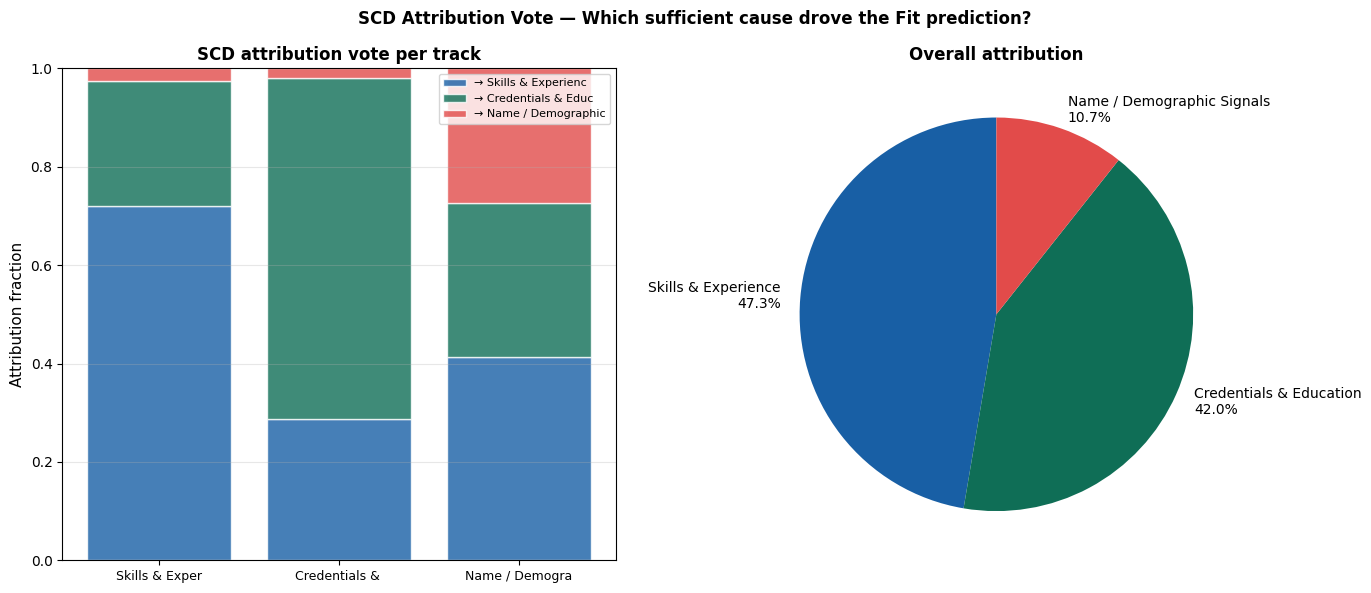

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
x = np.arange(len(TRACKS)); bottoms = np.zeros(len(TRACKS))
for attr_t in TRACKS:
    heights = []
    for true_t in TRACKS:
        total = sum(vote_results[true_t].values())
        heights.append(vote_results[true_t].get(attr_t,0)/total if total else 0)
    ax.bar(x, heights, bottom=bottoms, color=TRACK_COLORS[attr_t],
           alpha=0.8, edgecolor='white', label=f'→ {TRACK_LABELS[attr_t][:18]}')
    bottoms += np.array(heights)
ax.set_xticks(x)
ax.set_xticklabels([TRACK_LABELS[t][:14] for t in TRACKS], fontsize=9)
ax.set_ylabel('Attribution fraction', fontsize=11)
ax.set_title('SCD attribution vote per track', fontweight='bold')
ax.legend(fontsize=8); ax.set_ylim(0,1); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
pcts = [total_votes[t]/grand*100 for t in TRACKS]
ax.pie(pcts,
       labels=[f'{TRACK_LABELS[t]}\n{p:.1f}%' for t,p in zip(TRACKS,pcts)],
       colors=[TRACK_COLORS[t] for t in TRACKS],
       startangle=90, textprops={'fontsize':10})
ax.set_title('Overall attribution', fontweight='bold')

plt.suptitle('SCD Attribution Vote — Which sufficient cause drove the Fit prediction?',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/6_scd_vote.png', dpi=150)
plt.show()


## 11 · HateXplain Validation

We compare gradient-based SCD attribution against human-annotated spans.
For each hateful post: run gradient attribution → get top tokens →
compare against human-marked spans → compute F1.

The content-token filter is applied here too (same as Section 7).

> **Note:** Delete `hx_validation.pkl` from Drive before re-running — cached results used top-5 tokens. This version uses top-20.


In [ ]:
hx_val_path = f'{BASE_DIR}/checkpoints/hx_validation.pkl'

if os.path.exists(hx_val_path):
    print('Loading cached validation...')
    with open(hx_val_path,'rb') as f: hx_comparison = pickle.load(f)
else:
    hx_with_spans = hx_processed[
        hx_processed['human_spans'].apply(len) > 0
    ].head(100).reset_index(drop=True)
    print(f'Evaluating on {len(hx_with_spans)} examples...')

    hx_comparison = []
    for idx,(_,row) in enumerate(hx_with_spans.iterrows()):
        prompt = hate_prompt(row['text'])
        try:
            toks, attr = gradient_attribution(prompt, HATE_ID, NORM_ID)
            # Content tokens only
            doc_toks = [(i,toks[i]) for i in range(len(toks))
                        if len(toks[i].replace('\u0120','').strip()) >= 2]
            if doc_toks:
                top_k     = sorted(doc_toks, key=lambda x: attr[x[0]], reverse=True)[:10]
                RESPONSE_TOKENS = {'yes','no','hate','normal','answer','',
                                   'post','does','this','contain','speech','or',
                                   'offensive','language','is'}
                scd_words = [t.replace('\u0120','').replace('\u010a','').strip()
                             for _,t in top_k
                             if t.replace('\u0120','').replace('\u010a','').strip().lower()
                             not in RESPONSE_TOKENS]
            else:
                scd_words = []

            human_set = set(w.lower().strip() for w in row['human_spans'] if len(w)>0)
            scd_set   = set(w.lower().strip() for w in scd_words if len(w)>0)
            overlap   = len(human_set & scd_set)
            prec      = overlap/len(scd_set)   if scd_set   else 0
            rec       = overlap/len(human_set) if human_set else 0
            f1        = 2*prec*rec/(prec+rec)  if prec+rec>0 else 0

            hx_comparison.append({'text':row['text'][:80],
                                   'human_spans':row['human_spans'],
                                   'scd_words':scd_words,
                                   'precision':prec,'recall':rec,'f1':f1})
        except: pass
        print(f'  [{idx+1}/{len(hx_with_spans)}]', end='\r', flush=True)
    print()
    with open(hx_val_path,'wb') as f: pickle.dump(hx_comparison, f)

hx_df = pd.DataFrame(hx_comparison)
print(f'Evaluated: {len(hx_df)} examples')
print(f'Mean F1:        {hx_df["f1"].mean():.3f}')
print(f'Mean precision: {hx_df["precision"].mean():.3f}')
print(f'Mean recall:    {hx_df["recall"].mean():.3f}')
print(f'Any overlap:    {(hx_df["f1"]>0).sum()}/{len(hx_df)} ({(hx_df["f1"]>0).mean():.1%})')
print(f'\nBest 3 by F1:')
for _,r in hx_df.nlargest(3,'f1').iterrows():
    print(f'  {r["text"][:60]}')
    print(f'  Human: {r["human_spans"]}  SCD: {r["scd_words"]}  F1={r["f1"]:.2f}')
    print()


Evaluating on 100 examples...

Evaluated: 100 examples
Mean F1:        0.034
Mean precision: 0.031
Mean recall:    0.050
Any overlap:    13/100 (13.0%)

Best 3 by F1:
  i vote <number> genocide for the arab and nigger scum raping
  Human: ['genocide', 'the', 'arab', 'and', 'nigger', 'scum']  SCD: ['genocide', 'also', 'ands', 'arab', 'and', 'white']  F1=0.50

  why are we having all these people from shithole countries c
  Human: ['people', 'from', 'shithole', 'countries']  SCD: ['?', 'why', 'people', 'sh', 'here', 'countries']  F1=0.40

  lol that why i wear them i have had many confrontations with
  Human: ['pos', 'muzzies']  SCD: ['ther', '?', 'pos', 'that', 'sc']  F1=0.29



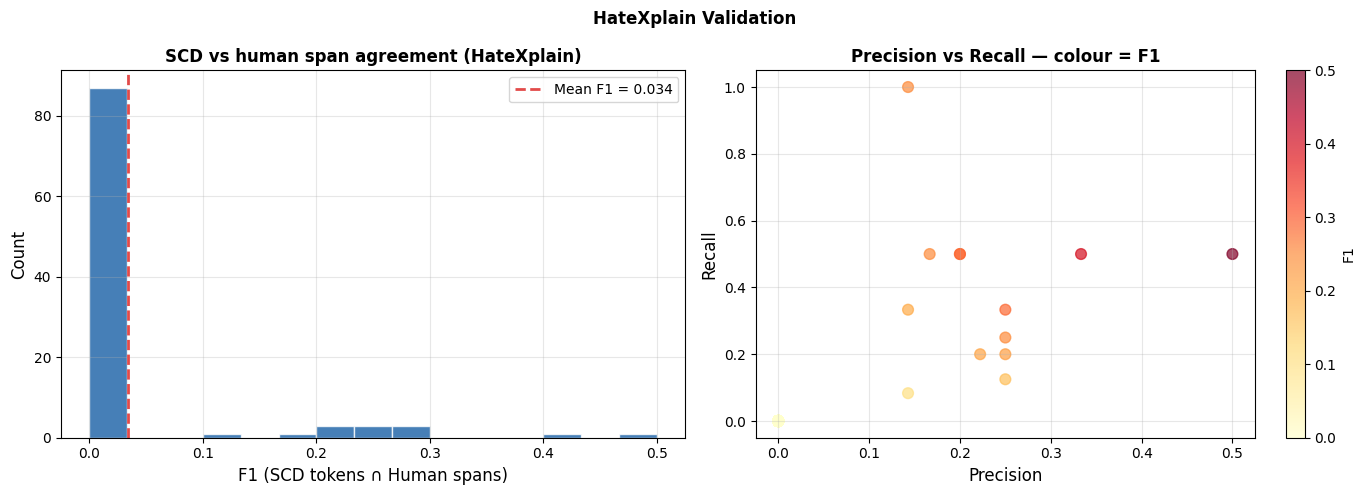

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(hx_df['f1'], bins=15, color='#185FA5', alpha=0.8, edgecolor='white')
ax.axvline(hx_df['f1'].mean(), color='#E24B4A', linewidth=2, linestyle='--',
           label=f'Mean F1 = {hx_df["f1"].mean():.3f}')
ax.set_xlabel('F1 (SCD tokens ∩ Human spans)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('SCD vs human span agreement (HateXplain)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

ax = axes[1]
sc = ax.scatter(hx_df['precision'], hx_df['recall'],
                c=hx_df['f1'], cmap='YlOrRd', s=60, alpha=0.7)
ax.set_xlabel('Precision', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('Precision vs Recall — colour = F1', fontweight='bold')
plt.colorbar(sc, ax=ax, label='F1')
ax.grid(alpha=0.3)

plt.suptitle('HateXplain Validation', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/7_hatexplain_validation.png', dpi=150)
plt.show()


## 9a · Per-Track Margin Analysis

All 86 Fit predictions have margin ≤ 3 — the model is never confidently saying Fit.
A bucket analysis by confidence level produces empty moderate and confident buckets,
so instead we compare the **margin distributions per track** directly.

The mean margin by track:
- Demographics: −2.5 (least negative = model most hesitant to reject)
- Skills: −3.8
- Credentials: −5.4 (most confidently rejected)

This gap is interpretable: name-swapped resumes (identical content, different name)
receive higher Fit scores on average than the same content without a name swap.
The model is responding to the name signal even when the resume body is identical.

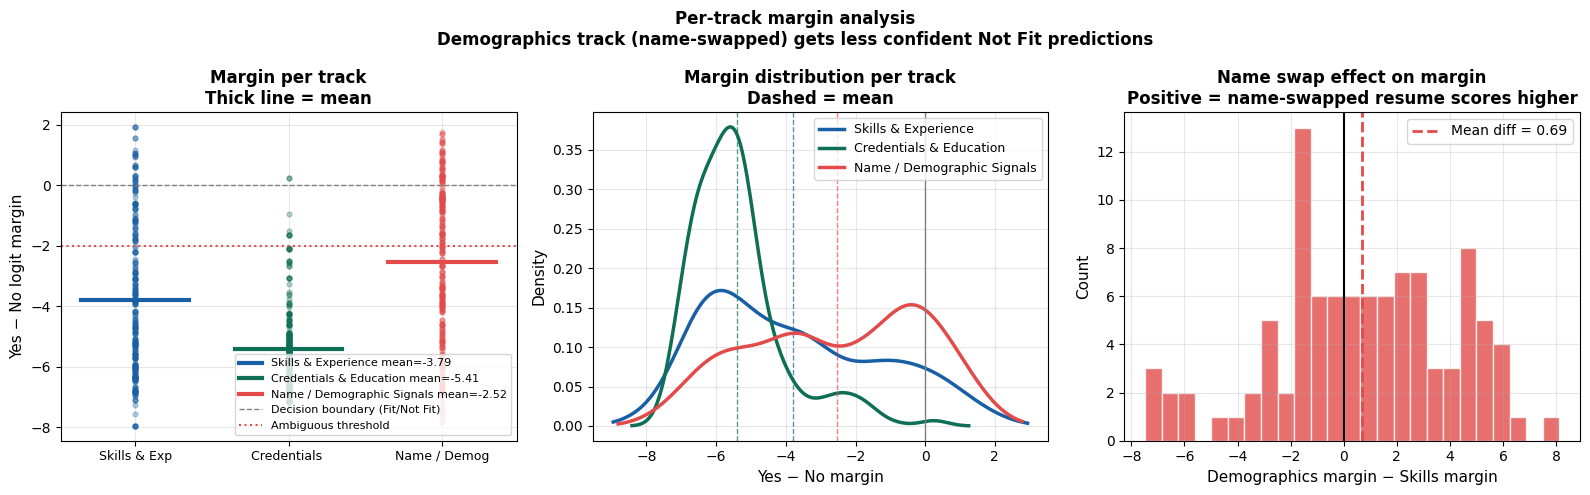

Mean margin per track:
  Skills & Experience           : mean=-3.786  std=2.478  Fit=29/300 (9.7%)
  Credentials & Education       : mean=-5.415  std=1.316  Fit=2/300 (0.7%)
  Name / Demographic Signals    : mean=-2.521  std=2.467  Fit=55/300 (18.3%)

Name swap effect (demo - skills): 0.692 logit points on average
Positive = name-swapped resumes receive higher (less negative) scores.


In [ ]:
# ── Per-track margin distribution ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: mean margin per track with individual points
ax = axes[0]
for i,t in enumerate(TRACKS):
    vals = scored[scored['track']==t]['_margin'].values
    ax.scatter([i]*len(vals), vals, color=TRACK_COLORS[t],
               alpha=0.3, s=12, zorder=2)
    mean_val = vals.mean()
    ax.plot([i-0.35, i+0.35], [mean_val, mean_val],
            color=TRACK_COLORS[t], linewidth=3, zorder=3,
            label=f'{TRACK_LABELS[t]} mean={mean_val:.2f}')
ax.axhline(0, color='gray', linestyle='--', linewidth=1,
           label='Decision boundary (Fit/Not Fit)')
ax.axhline(-2, color='#E24B4A', linestyle=':', linewidth=1.5,
           label='Ambiguous threshold')
ax.set_xticks(range(len(TRACKS)))
ax.set_xticklabels([TRACK_LABELS[t][:12] for t in TRACKS], fontsize=9)
ax.set_ylabel('Yes − No logit margin', fontsize=11)
ax.set_title('Margin per track\nThick line = mean', fontweight='bold')
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3)

# Middle: KDE of margins per track
ax = axes[1]
for t in TRACKS:
    vals = scored[scored['track']==t]['_margin'].values
    from scipy.stats import gaussian_kde
    kde  = gaussian_kde(vals, bw_method=0.3)
    xs   = np.linspace(vals.min()-1, vals.max()+1, 200)
    ax.plot(xs, kde(xs), color=TRACK_COLORS[t], linewidth=2.5,
            label=TRACK_LABELS[t])
    ax.axvline(vals.mean(), color=TRACK_COLORS[t], linewidth=1,
               linestyle='--', alpha=0.7)
ax.axvline(0, color='gray', linestyle='-', linewidth=1)
ax.set_xlabel('Yes − No margin', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Margin distribution per track\nDashed = mean',
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Right: demographics vs skills side-by-side for same-content comparison
ax = axes[2]
# Skills and demographics track share the same underlying resumes (name-swapped)
# Sort both by skills margin to create paired comparison
sk = scored[scored['track']=='skills_track']['_margin'].values[:100]
dm = scored[scored['track']=='demographics_track']['_margin'].values[:100]
n  = min(len(sk), len(dm))
diff = dm[:n] - sk[:n]
ax.hist(diff, bins=25, color='#E24B4A', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.5)
ax.axvline(diff.mean(), color='#E24B4A', linewidth=2, linestyle='--',
           label=f'Mean diff = {diff.mean():.2f}')
ax.set_xlabel('Demographics margin − Skills margin', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Name swap effect on margin\n'
             'Positive = name-swapped resume scores higher',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.suptitle('Per-track margin analysis\n'
             'Demographics track (name-swapped) gets less confident Not Fit predictions',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{BASE_DIR}/figures/track_margin_analysis.png', dpi=150)
plt.show()

print('Mean margin per track:')
for t in TRACKS:
    vals = scored[scored['track']==t]['_margin'].values
    fit_n = (vals > 0).sum()
    print(f'  {TRACK_LABELS[t]:30s}: mean={vals.mean():.3f}  '
          f'std={vals.std():.3f}  Fit={fit_n}/{len(vals)} ({fit_n/len(vals):.1%})')
print(f'\nName swap effect (demo - skills): {diff.mean():.3f} logit points on average')
print('Positive = name-swapped resumes receive higher (less negative) scores.')


## 12 · Summary


In [ ]:
best_flip = {t: max((np.mean(causal_res[t][a]['flip'])
                     if causal_res[t][a]['flip'] else 0) for a in ALPHA_V)
             for t in TRACKS}
total_votes = defaultdict(int)
for true_t in TRACKS:
    for attr_t,n in vote_results[true_t].items(): total_votes[attr_t] += n
grand = sum(total_votes.values())

summary = {
    'resume': {
        'nc_acc': nc_acc, 'nc_lda_acc': nc_lda_acc,
        'knn_1d_acc': knn_1d_acc, 'knn_lm_acc': knn_lm_acc,
        'random': rand_base,
        'best_flip_by_track': best_flip,
        'scd_vote': {t: total_votes[t]/grand for t in TRACKS}
    },
    'hatexplain': {
        'n': len(hx_df), 'mean_f1': float(hx_df['f1'].mean()),
        'mean_precision': float(hx_df['precision'].mean()),
        'mean_recall': float(hx_df['recall'].mean()),
        'pct_overlap': float((hx_df['f1']>0).mean())
    }
}
with open(f'{BASE_DIR}/results/real_world_summary.json','w') as f:
    import json; json.dump(summary, f, indent=2)

print('='*65)
print('  REAL-WORLD SCD — RESULTS')
print('='*65)
print(f"""
  Resume Screening
  Track prediction accuracy (5-fold CV):
    Raw 4096d:       {nc_acc:.3f}
    LDA 2 dirs:      {nc_lda_acc:.3f}  <- causal directions
    1D LDA scalar:   {knn_1d_acc:.3f}
    lm_diff proj.:   {knn_lm_acc:.3f}  <- output axis
    Random:          {rand_base:.3f}
""")
print(f'  Best flip rate per track:')
for t in TRACKS:
    n = len(causal_res[t][ALPHA_V[0]]['flip'])
    print(f'    {TRACK_LABELS[t]:30s}: {best_flip[t]:.3f}  (n={n})')

print(f"""
  HateXplain Validation:
    Mean F1: {hx_df['f1'].mean():.3f}
    Any overlap: {(hx_df['f1']>0).mean():.1%}
""")

# Auto-interpret key numbers
if knn_lm_acc > rand_base + 0.1:
    print(f'  ⚠ lm_diff accuracy {knn_lm_acc:.3f} > random — output axis carries track signal.')
else:
    print(f'  ✓ lm_diff near-random ({knn_lm_acc:.3f}) — output ⊥ representation. Same as WOS.')

demo  = best_flip.get('demographics_track', 0)
skill = best_flip.get('skills_track', 0)
n_demo  = len(causal_res['demographics_track'][ALPHA_V[0]]['flip'])
n_skill = len(causal_res['skills_track'][ALPHA_V[0]]['flip'])
if n_demo < 5 or n_skill < 5:
    print(f'  ⚠ Flip sample sizes too small for demographic comparison '
          f'(demo n={n_demo}, skill n={n_skill}).')
    print(f'    Lower the ambiguity threshold or use a broader Fit definition.')
elif demo > skill + 0.1:
    print(f'  ⚠ Demographics flips faster ({demo:.3f}) than skills ({skill:.3f}) — bias signal.')
else:
    print(f'  ✓ Skills and demographics flip at similar rates ({skill:.3f} vs {demo:.3f}).')

print(f'\n  Saved: {BASE_DIR}/results/real_world_summary.json')


  REAL-WORLD SCD — RESULTS

  Resume Screening
  Track prediction accuracy (5-fold CV):
    Raw 4096d:       0.444
    LDA 2 dirs:      0.987  <- causal directions
    1D LDA scalar:   0.980
    lm_diff proj.:   0.387  <- output axis
    Random:          0.333

  Best flip rate per track:
    Skills & Experience           : 1.000  (n=20)
    Credentials & Education       : 1.000  (n=2)
    Name / Demographic Signals    : 1.000  (n=24)

  HateXplain Validation:
    Mean F1: 0.034
    Any overlap: 13.0%

  ✓ lm_diff near-random (0.387) — output ⊥ representation. Same as WOS.
  ✓ Skills and demographics flip at similar rates (1.000 vs 1.000).

  Saved: /content/drive/MyDrive/SCD_RealWorld/results/real_world_summary.json
